In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import sys
import random
from sklearn.metrics import accuracy_score
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear   = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        self.out_linear   = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.n_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query = self.split_heads(self.query_linear(query), batch_size)
        key   = self.split_heads(self.key_linear(key), batch_size)
        value = self.split_heads(self.value_linear(value), batch_size)

        attention_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            attention_scores += mask
        attention_weights = F.softmax(attention_scores, dim=-1)
        context = torch.matmul(attention_weights, value)
        context = context.permute(0, 2, 1, 3).contiguous().view(batch_size, -1, self.d_model)
        output = self.out_linear(context)
        return output

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_output = self.attention(x, x, x, mask)
        x = self.layer_norm1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.layer_norm2(x + ffn_output)
        return x

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, 1000, d_model))
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, 1000, d_model))
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.output_linear = nn.Linear(d_model, vocab_size)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        x = self.embedding(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)
        logits = self.output_linear(x)
        return logits


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.attention1 = MultiHeadAttention(d_model, n_heads)
        self.attention2 = MultiHeadAttention(d_model, n_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.layer_norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        if tgt_padding_mask is not None:
            expanded_tgt_padding_mask = tgt_padding_mask.unsqueeze(1).unsqueeze(2)
            padding_mask = expanded_tgt_padding_mask.float() * -1e9
            if tgt_mask is not None:
                expanded_tgt_mask = tgt_mask.unsqueeze(0)
                expanded_tgt_mask = expanded_tgt_mask.unsqueeze(1)
                combined_tgt_mask = expanded_tgt_mask + padding_mask
            else:
                combined_tgt_mask = padding_mask
        else:
            combined_tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(1) if tgt_mask is not None else None

        attn1_output = self.attention1(x, x, x, mask=combined_tgt_mask)
        x = self.layer_norm1(x + self.dropout(attn1_output))

        if src_padding_mask is not None:
            expanded_src_padding_mask = src_padding_mask.unsqueeze(1).unsqueeze(2)
            cross_mask = expanded_src_padding_mask.float() * -1e9
        else:
            cross_mask = None

        attn2_output = self.attention2(x, enc_output, enc_output, mask=cross_mask)
        x = self.layer_norm2(x + self.dropout(attn2_output))

        ffn_output = self.ffn(x)
        x = self.layer_norm3(x + self.dropout(ffn_output))
        return x

class Transformer(torch.nn.Module):
    def __init__(self, en_vocab_size, vi_vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(en_vocab_size, d_model, n_heads, n_layers, d_ff, dropout)
        self.decoder = Decoder(vi_vocab_size, d_model, n_heads, n_layers, d_ff, dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        enc_output = self.encoder(src, src_mask)
        logits = self.decoder(tgt, enc_output, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)
        return logits

def generate_square_subsequent_mask(sz, DEVICE):
    mask = (torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt, DEVICE, PAD_IDX):
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, DEVICE)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX)
    tgt_padding_mask = (tgt == PAD_IDX)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

In [2]:
def train(model, train_loader, valid_loader, criterion, optimizer, device, pad_in_token_id, pad_out_token_id, num_epochs=10):
    train_losses = []
    train_accuracies = []
    valid_accuracies = []
    valid_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_batches = len(train_loader)

        for batch_idx, batch in enumerate(train_loader):
            encoder_input, decoder_target = batch
            encoder_input = encoder_input.to(device)
            decoder_target = decoder_target.to(device).long()

            tgt_input = decoder_target[:, :-1]
            tgt_out = decoder_target[:, 1:]

            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(encoder_input, tgt_input, device, pad_in_token_id)

            optimizer.zero_grad()

            outputs = model(encoder_input, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)

            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), tgt_out.reshape(-1))
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            sys.stdout.write(f"\rEpoch [{epoch + 1:2d}/{num_epochs}] Batch [{batch_idx + 1}/{total_batches}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

        avg_train_loss = running_loss / total_batches
        train_losses.append(avg_train_loss)

        print(f"\nEvaluating metrics for epoch {epoch + 1}...")

        # Evaluate on training set
        print("Evaluating on training set...")
        model.eval()

        # Standard evaluation on training set
        train_accuracy, _ = evaluate(model, train_loader, criterion, device, pad_in_token_id)
        train_accuracies.append(train_accuracy)

        # Evaluate on validation set
        print("Evaluating on validation set...")
        # Standard evaluation
        valid_accuracy, valid_loss = evaluate(model, valid_loader, criterion, device, pad_in_token_id)
        valid_accuracies.append(valid_accuracy)
        valid_losses.append(valid_loss)

        # Print metrics summary
        print(f"\nEpoch [{epoch + 1:2d}/{num_epochs}] Summary:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss: {valid_loss:.4f}, Val Acc: {valid_accuracy:.4f}")
        
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'valid_losses': valid_losses,
        'valid_accuracies': valid_accuracies,
    }

def evaluate(model, valid_loader, criterion, device, pad_token_id):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    total_batches = len(valid_loader)

    with torch.no_grad():
        for batch_idx, batch in enumerate(valid_loader):
            encoder_input, decoder_target = batch
            encoder_input = encoder_input.to(device)
            decoder_target = decoder_target.to(device)

            tgt_input = decoder_target[:, :-1]
            tgt_out = decoder_target[:, 1:]

            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(encoder_input, tgt_input, device, pad_token_id)

            outputs = model(encoder_input, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)

            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), tgt_out.reshape(-1))
            running_loss += loss.item()

            _, predicted = torch.max(outputs, dim=-1)
            all_preds.extend(predicted.reshape(-1).cpu().numpy())
            all_labels.extend(tgt_out.reshape(-1).cpu().numpy())

            sys.stdout.write(f"\rBatch [{batch_idx + 1}/{total_batches}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

    accuracy = accuracy_score(all_labels, all_preds)
    avg_valid_loss = running_loss / total_batches
    return accuracy, avg_valid_loss

In [3]:
import string
import torch
from torch.utils.data import Dataset

class TranslationDatasetFull(Dataset):
    def __init__(self, in_file, out_file, in_vocab, out_vocab, max_len=50):
        self.in_sentences = self._load_sentences(in_file)
        self.out_sentences = self._load_sentences(out_file)
        self.in_vocab = in_vocab
        self.out_vocab = out_vocab
        self.max_len = max_len

    def _load_sentences(self, file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        return sentences

    def _encode_sentence(self, sentence, vocab, max_len):
        sentence = sentence.strip().lower()
        sentence = sentence.translate(str.maketrans("", "", string.punctuation))
        tokens = sentence.split()
        token_ids = [vocab.get(token, vocab['<unk>']) for token in tokens]
        token_ids = token_ids[:max_len] + [vocab['<pad>']] * (max_len - len(token_ids))
        return token_ids

    def _encode_decoder_sentence(self, sentence, vocab, max_len):
        sentence = sentence.strip().lower()
        sentence = sentence.translate(str.maketrans("", "", string.punctuation))
        tokens = sentence.split()
        full_tokens = [vocab['<seqstart>']] + [vocab.get(token, vocab['<unk>']) for token in tokens] + [vocab['<seqend>']]
        if len(full_tokens) < max_len:
            full_tokens += [vocab['<pad>']] * (max_len - len(full_tokens))
        else:
            full_tokens = full_tokens[:max_len]
        return full_tokens

    def __len__(self):
        return len(self.in_sentences)

    def __getitem__(self, idx):
        in_sentence = self.in_sentences[idx]
        out_sentence = self.out_sentences[idx]

        src = self._encode_sentence(in_sentence, self.in_vocab, self.max_len)
        tgt = self._encode_decoder_sentence(out_sentence, self.out_vocab, self.max_len)
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

In [4]:
import pickle
import os

def build_vocab(file_path=None, max_len=10000, vocab_path=None):
    if vocab_path is not None and os.path.exists(vocab_path):
        with open(vocab_path, 'rb') as f:
            vocab = pickle.load(f)
        print(f"Vocab loaded from {vocab_path}")
        return vocab

    elif file_path:
        print(f"Vocab not found at {vocab_path}, building vocab from scratch.")

        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = f.readlines()

        all_words = []
        for index, sentence in enumerate(sentences):
            sentence = sentence.strip().lower()
            sentence = sentence.translate(str.maketrans("", "", string.punctuation))
            all_words.extend(sentence.split())

            sys.stdout.write(f"\rProcessing {file_path}, {index + 1:6d} | {len(sentences)}")
            sys.stdout.flush()

        word_counts = Counter(all_words)

        # special token
        vocab = {
            "<pad>": 0,
            "<unk>": 1,
            "<seqstart>": 2,
            "<seqend>": 3
        }

        # create new id
        start_idx = len(vocab)
        for idx, (word, _) in enumerate(word_counts.most_common(max_len), start=start_idx):
            if word not in vocab:
                vocab[word] = idx

        print()

        if vocab_path is not None:
            with open(vocab_path, 'wb') as f:
                pickle.dump(vocab, f)

        return vocab

    else:
        raise ValueError("No vocab file found and no file_path provided to build from.")


In [5]:
import os

def evaluate_model_on_test(model, test_dataloader, criterion, device, pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform):
    """Evaluate model on test set with all metrics"""
    print("\n===== Evaluating Model on Test Set =====")

    # Standard evaluation
    test_accuracy, test_loss = evaluate(model, test_dataloader, criterion, device, pad_in_token_id)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    return {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
    }


def visualize_metrics(metrics, save_path=None):
    """Visualize all training and validation metrics"""
    plt.figure(figsize=(20, 15))

    # Plot 1: Train and Validation Loss
    plt.subplot(2, 2, 1)
    plt.plot(metrics['train_losses'], label='Training Loss')
    plt.plot(metrics['valid_losses'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Token Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(metrics['train_accuracies'], label='Train Token Accuracy', color='blue')
    plt.plot(metrics['valid_accuracies'], label='Val Token Accuracy', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Token Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)

    plt.show()

    # Create a separate figure for comparing final metrics
    plt.figure(figsize=(12, 8))

    metrics_names = ['Token Accuracy']
    train_values = [metrics['train_accuracies'][-1] * 100]
    val_values = [metrics['valid_accuracies'][-1] * 100]

    x = np.arange(len(metrics_names))
    width = 0.35

    plt.bar(x - width/2, train_values, width, label='Train', color='blue', alpha=0.7)
    plt.bar(x + width/2, val_values, width, label='Validation', color='orange', alpha=0.7)

    plt.ylabel('Score (%)')
    plt.title('Final Training vs. Validation Metrics')
    plt.xticks(x, metrics_names)
    plt.legend()

    # Add values on top of bars
    for i, v in enumerate(train_values):
        plt.text(i - width/2, v + 1, f"{v:.2f}%", ha='center')

    for i, v in enumerate(val_values):
        plt.text(i + width/2, v + 1, f"{v:.2f}%", ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_comparison{ext}")

    plt.show()


def train_and_evaluate_model(model, train_dataloader, val_dataloader, test_dataloader, criterion, optimizer, device,
                             pad_in_token_id, pad_out_token_id,
                             num_epochs=10):

    # Train the model
    print("Starting training...")
    metrics = train(model, train_dataloader, val_dataloader, criterion, optimizer, device,
                   pad_in_token_id, pad_out_token_id,
                   num_epochs=num_epochs)

    return metrics


def plot_metric_trends(metrics):
    """Create more detailed trend visualizations for each metric"""

    # 1. Token Accuracy Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_accuracies'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_accuracies'], marker='s', linestyle='-', label='Validation')
    plt.title('Token-level Accuracy Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("token_accuracy_trends.png")
    plt.show()

    # 4. Loss Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_losses'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_losses'], marker='s', linestyle='-', label='Validation')
    plt.title('Loss Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("loss_trends.png")
    plt.show()

In [8]:
import pickle

DIM_MODEL = 512
LEARNING_RATE = 0.0001
BATCH = 512

in_vocab = build_vocab(file_path="", max_len=10000, vocab_path="vocab/in_vocab.pkl")
out_vocab = build_vocab(file_path="", max_len=10000, vocab_path="vocab/in_vocab.pkl")

N_HEADS = 8
N_LAYERS = 4
D_FF = 512
DROPOUT = 0.1

IN_VOCAB_SIZE = len(in_vocab)
OUT_VOCAB_SIZE = len(out_vocab)

BOS_IDX = out_vocab['<seqstart>']
EOS_IDX = out_vocab['<seqend>']

print(f"Input vocab size: {IN_VOCAB_SIZE}, Output vocab size: {OUT_VOCAB_SIZE}")

Vocab loaded from vocab/in_vocab.pkl
Vocab loaded from vocab/in_vocab.pkl
Input vocab size: 1122, Output vocab size: 1122


In [9]:
def generate_square_subsequent_mask(sz, DEVICE):
    mask = (torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask


def greedy_decode(model, src, src_mask, max_len, start_symbol, DEVICE):
    src = src.to(DEVICE)
    src_mask = src_mask.to(DEVICE)

    memory = model.encoder(src, src_mask)

    ys = torch.ones(src.size(0), 1).fill_(start_symbol).type(torch.long).to(DEVICE)

    for i in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), DEVICE).to(DEVICE)

        out = model.decoder(ys, memory, src_mask, tgt_mask, None, None)

        out_last = out[:, -1, :]

        prob = out_last
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat([ys, torch.tensor([[next_word]], device=DEVICE)], dim=1)

        if next_word == EOS_IDX:
            break

    return ys

def simple_text_transform(sentence: str):
    sentence = sentence.strip().lower()
    sentence = sentence.translate(str.maketrans("", "", string.punctuation))
    tokens = sentence.split()
    token_ids = [in_vocab.get(token, in_vocab['<unk>']) for token in tokens]
    return torch.tensor(token_ids, dtype=torch.long).unsqueeze(0)

class SimpleVocab:
    def __init__(self, vocab):
        self.vocab = vocab
        self.inv_vocab = {id: token for token, id in vocab.items()}
    def lookup_tokens(self, ids):
        return [self.inv_vocab.get(i, "<unk>") for i in ids]

out_vocab_transform = SimpleVocab(out_vocab)
in_vocab_transform = SimpleVocab(in_vocab)

In [8]:
from torch.utils.data import DataLoader

train_output_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/train/label.txt"
train_input_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/train/source.txt"

train_dataset = TranslationDatasetFull(train_input_file, train_output_file, in_vocab, out_vocab, max_len=50)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)

val_output_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/val/label.txt"
val_input_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/val/source.txt"

val_dataset = TranslationDatasetFull(val_input_file, val_output_file, in_vocab, out_vocab, max_len=50)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH, shuffle=True)

test_output_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/test/label.txt"
test_input_file = "/kaggle/input/datasets/ltrungphong/nlp-1234/dataset/test/source.txt"

test_dataset = TranslationDatasetFull(test_input_file, test_output_file, in_vocab, out_vocab, max_len=50)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = Transformer(IN_VOCAB_SIZE, OUT_VOCAB_SIZE, DIM_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT)
model = model.to(device)

cuda


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98))

In [11]:
pad_out_token_id = out_vocab.get('<pad>', 0)
pad_in_token_id = in_vocab.get('<pad>', 0)

print(pad_out_token_id, pad_in_token_id)

0 0


In [12]:
metrics = train_and_evaluate_model(
    model, train_dataloader, val_dataloader, test_dataloader,
    criterion, optimizer, device,
    pad_in_token_id, pad_out_token_id,
    num_epochs=6
)

Starting training...
Epoch [ 1/6] Batch [125/125], Loss: 1.5301
Evaluating metrics for epoch 1...
Evaluating on training set...
Batch [125/125], Loss: 1.4316Evaluating on validation set...
Batch [42/42], Loss: 1.4987
Epoch [ 1/6] Summary:
Train Loss: 1.7424, Train Acc: 0.7875
Val Loss: 1.4859, Val Acc: 0.7869
Epoch [ 2/6] Batch [125/125], Loss: 0.9683
Evaluating metrics for epoch 2...
Evaluating on training set...
Batch [125/125], Loss: 0.8925Evaluating on validation set...
Batch [42/42], Loss: 0.8830
Epoch [ 2/6] Summary:
Train Loss: 1.3469, Train Acc: 0.8821
Val Loss: 0.8899, Val Acc: 0.8814
Epoch [ 3/6] Batch [125/125], Loss: 0.2972
Evaluating metrics for epoch 3...
Evaluating on training set...
Batch [125/125], Loss: 0.2507Evaluating on validation set...
Batch [42/42], Loss: 0.2544
Epoch [ 3/6] Summary:
Train Loss: 0.5289, Train Acc: 0.9441
Val Loss: 0.2625, Val Acc: 0.9435
Epoch [ 4/6] Batch [125/125], Loss: 0.1866
Evaluating metrics for epoch 4...
Evaluating on training set...
Ba

In [13]:
from pprint import pprint
pprint(metrics)

{'train_accuracies': [0.787523757801802,
                      0.8820945752872886,
                      0.9441335270673717,
                      0.9546426727634781,
                      0.9641167397639114,
                      0.9736974434961012],
 'train_losses': [1.7423680696487427,
                  1.3468926649093629,
                  0.5288920907974243,
                  0.22900523674488069,
                  0.15634402203559875,
                  0.11838684421777725],
 'valid_accuracies': [0.7868651003837964,
                      0.8814359178692832,
                      0.9434908332319646,
                      0.9535431011941079,
                      0.9622630485525979,
                      0.9709782068363084],
 'valid_losses': [1.485944730894906,
                  0.8899201367582593,
                  0.2625397663740885,
                  0.1653831647265525,
                  0.12421767573271479,
                  0.09492386327612967]}


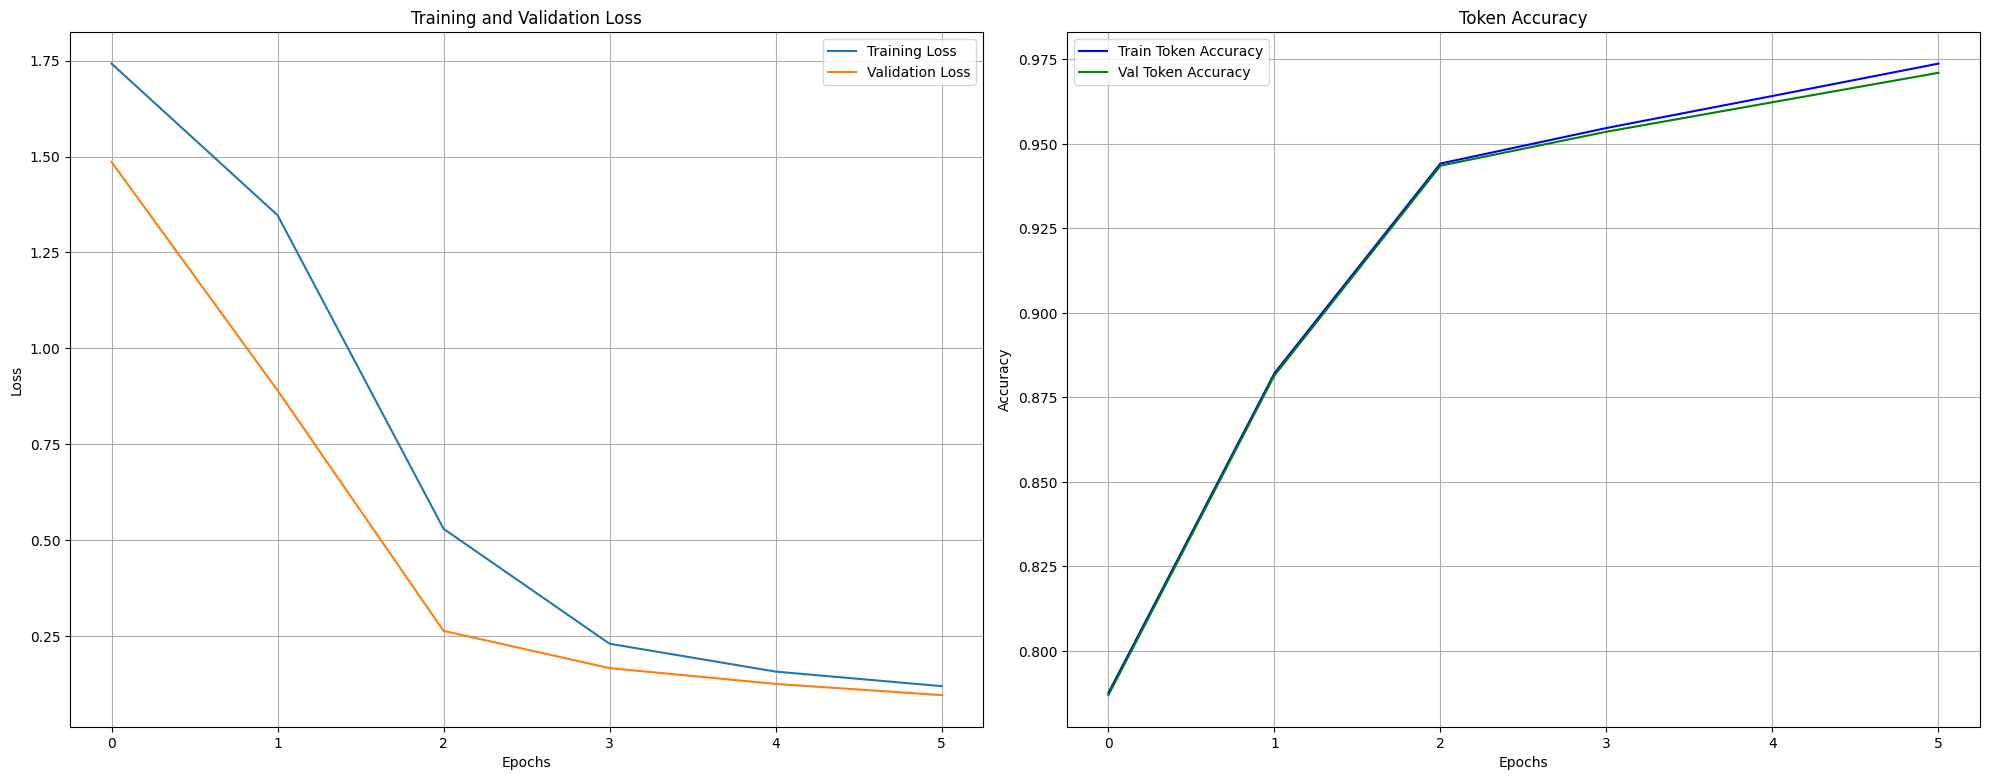

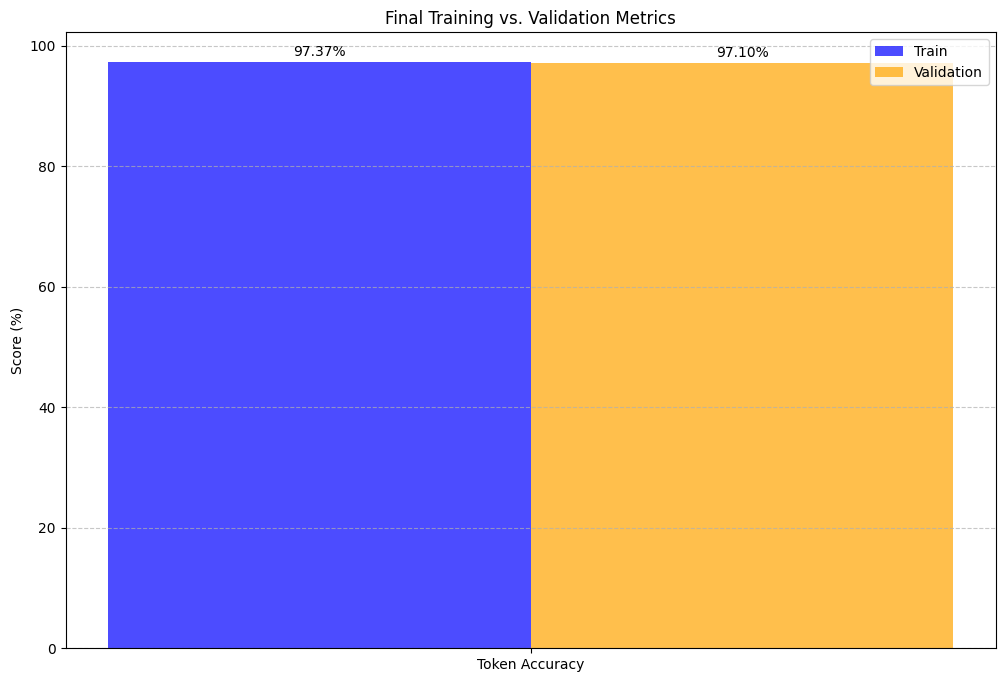

In [14]:
# Visualize training metrics
visualize_metrics(metrics, save_path="training_metrics.png")

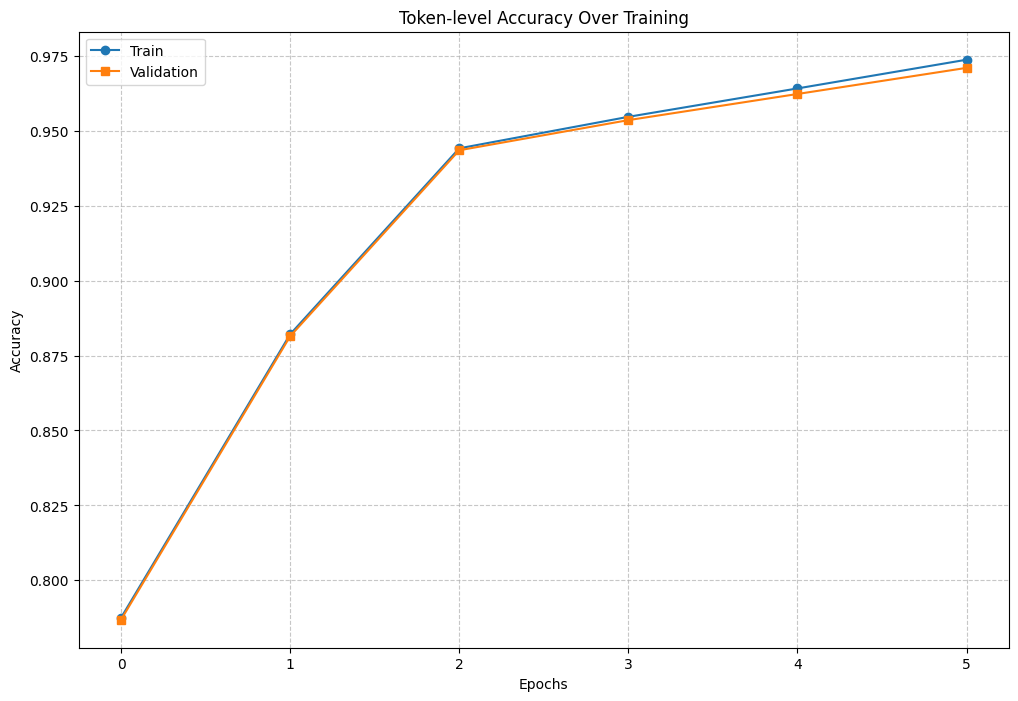

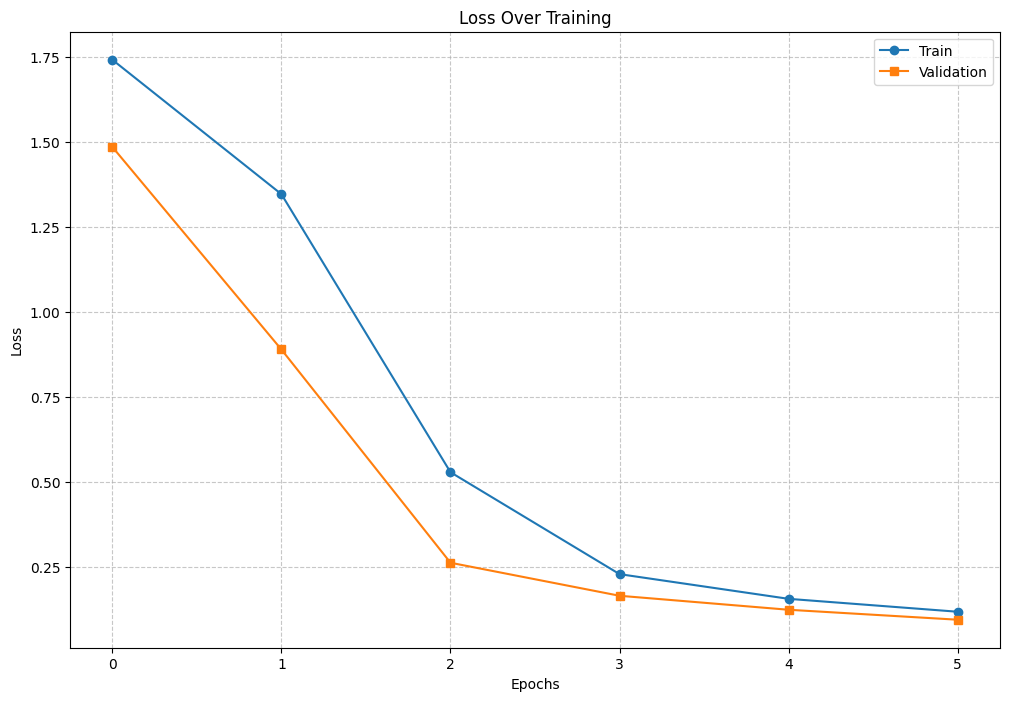

In [15]:
# Plot metric trends separately
plot_metric_trends(metrics)

In [16]:
torch.save(model.state_dict(), "trained_model.pth")

In [17]:
test_results = evaluate_model_on_test(model, test_dataloader, criterion, device,
                                        pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX,
                                        in_vocab_transform, out_vocab_transform)

plt.figure(figsize=(10, 6))
metrics_names = ['Token Accuracy']
test_values = [test_results['test_accuracy'] * 100]

train_values = [metrics['train_accuracies'][-1] * 100]

val_values = [metrics['valid_accuracies'][-1] * 100]


===== Evaluating Model on Test Set =====
Batch [666/666], Loss: 0.1126Test Loss: 0.0952, Test Accuracy: 0.9710


<Figure size 1000x600 with 0 Axes>

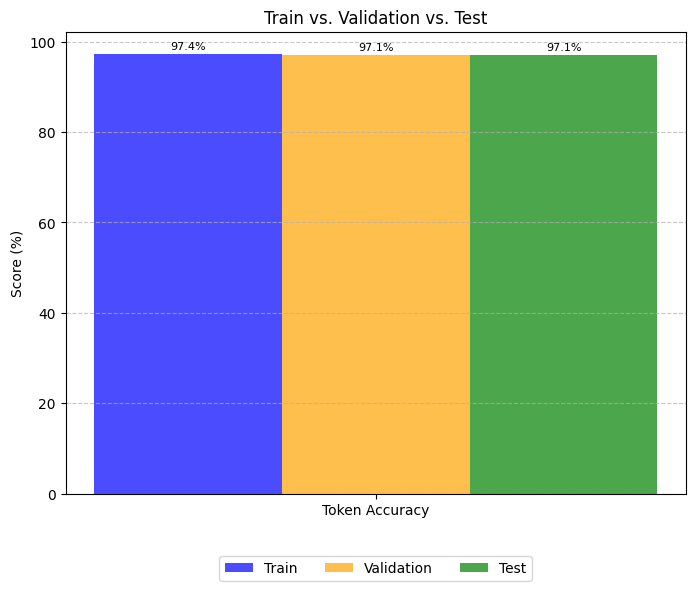

In [18]:
x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(8, 6))
plt.bar(x - width, train_values, width, label='Train', color='blue', alpha=0.7)
plt.bar(x, val_values, width, label='Validation', color='orange', alpha=0.7)
plt.bar(x + width, test_values, width, label='Test', color='green', alpha=0.7)

plt.ylabel('Score (%)')
plt.title('Train vs. Validation vs. Test')
plt.xticks(x, metrics_names)
plt.legend()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

for i, v in enumerate(train_values):
    plt.text(i - width, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

for i, v in enumerate(val_values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

for i, v in enumerate(test_values):
    plt.text(i + width, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("final_metrics_comparison.png")
plt.show()

In [ ]:
import torch

def translate(model: torch.nn.Module, src_sentence: str, DEVICE):
    model.eval()
    src_tensor = simple_text_transform(src_sentence).to(DEVICE)
    seq_len = src_tensor.size(1)
    src_mask = torch.zeros(seq_len, seq_len, device=DEVICE).type(torch.bool)

    ys = greedy_decode(model, src_tensor, src_mask, max_len=seq_len + 5, start_symbol=BOS_IDX, DEVICE=DEVICE)
    tgt_tokens = ys.squeeze(0).cpu().numpy().tolist()

    tokens = out_vocab_transform.lookup_tokens(tgt_tokens)
    num_words = len(src_sentence.split())
    translation = " ".join(tokens).replace("<seqstart>", "").replace("<seqend>", "").strip()
    if len(translation.split()) > num_words:
        translation = " ".join(translation.split()[:num_words])
    return translation

# import os
# print(os.getcwd())
# os.listdir(os.getcwd())

import torch

# Khai báo thiết bị CPU
device = torch.device("cpu")

# Khởi tạo mô hình
model = Transformer(IN_VOCAB_SIZE, OUT_VOCAB_SIZE, DIM_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT)

# Load model ép sang CPU
model.load_state_dict(torch.load("trained_model.pth", map_location=device))

# Đặt model về chế độ eval nếu chỉ dùng inference
model.eval()

# Bây giờ bạn có thể dùng model để dự đoán

In [20]:
test_sentence = "van phong cua anh ay thuan tien den ga"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: van phong cua anh ay thuan tien den ga
Translated sentence: văn phòng của anh ấy thuận tiện đến ga


In [21]:
test_sentence = "chung toi muon tham du buoi hoa nhac toi nay."
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: chung toi muon tham du buoi hoa nhac toi nay.
Translated sentence: chúng tôi muốn tham dự buổi hoa nhắc tôi này


In [22]:
test_sentence = "ti nua ve nha dan ba noi di hoc boi"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: ti nua ve nha dan ba noi di hoc boi
Translated sentence: nhưng nửa về nhà dân ba nơi đi học bởi
